# Majorant_v2 — four cascades, BASELINE engine (no resampling, no thinning)

Uses **`BF_v_no_resampling.py`**: one simulated particle is one physical particle, $w\equiv1$
for the whole run. There is no weight bookkeeping anywhere, so

- $\sum w$ and $\sum wm$ are conserved to machine precision — `mass_drift` is *identically zero*
  and any nonzero value is a bug, not a fluctuation;
- the clock is simply $dt=2V/R$, with nothing that can silently rescale it;
- nothing is resampled, so nothing can bias the answer.

The price is **range**. In a closed box $N=N_{\rm i}m_{\rm i}/m_0$, so reaching $D$ decades while
keeping $K$ particles alive at the top needs $N_{\rm i}\ge K\cdot10^{D}$ — about
$D\le\log_{10}N_{\rm i}-3$ decades for usable statistics. Fragmentation fails the other way:
$N$ grows as $m_{\rm i}/m_0$, so three decades multiply the population a thousandfold and memory,
not physics, ends the run. Section 5 measures both walls.

For ten decades use `BF.py` (multiplication + down-sampling); the two agree wherever both can run.

| # | process | system | boundary conditions |
|---|---|---|---|
| 1 | coagulation  | closed | none — mass exactly conserved |
| 2 | fragmentation| closed | passive floor only — mass exactly conserved |
| 3 | coagulation  | open   | injection at small $m$, absorbing sink at large $m$ |
| 4 | fragmentation| open   | injection at large $m$, absorbing sink at small $m$ |

## What the analytic part predicts

$$\frac{dm_0}{d\tau}=\int n(m)\,K(m_0,m)\,\Delta m(m_0,m)\,dm ,\qquad x=m/m_0,\ dm=m_0\,dx$$

Kernel homogeneity, the per-event mass change and the Jacobian always contribute
$m_0^{\lambda}\cdot m_0\cdot m_0$, so the only difference between the four cases is the power of
$m_0$ carried by $n$:

$$\beta=\lambda+2+\begin{cases}-2 & \text{closed: packet}\propto m_0^{-2}\\ \ \ \alpha & \text{open: background}\propto m_0^{\alpha}\end{cases}
\qquad b=\frac{1}{1-\beta},\qquad \alpha=-(1+\beta)$$

| | $\beta$ | $b$ | $\alpha$ |
|---|---|---|---|
| **closed** | $\lambda$ | $1/(1-\lambda)$ | $-(1+\lambda)$ |
| **open**   | $(1+\lambda)/2$ | $2/(1-\lambda)$ | $-(3+\lambda)/2$ |

Coagulation and fragmentation share $\beta$, $b$ and $\alpha$ exactly — only the sign of the drift
flips, so the law is read in $\tau$ going up and in $\tau_*-\tau$ going down. $b_{\rm open}=2b_{\rm closed}$
always; the branches meet only at $\lambda=1$, where $\beta=1$, the drift is exponential and both
give $\alpha=-2$ — the gelation threshold.

**Constant kernel, $\lambda=0$:** closed $b=1$, $\alpha=-1$;  open $b=2$, $\alpha=-3/2$.

## How the spectrum is measured — differently in the two systems

- **Closed**: no steady state exists. Use the superposition $F(m)=\sum_t(dN/dm)\Delta t$
  (`BF.superpose`), and place snapshots with `snapshot_mode="log_m0"`.
- **Open**: the steady state *is* the instantaneous spectrum — use the **last snapshot**.
  $\Delta t$ never enters, so the cadence is irrelevant there.



> ### ⚠ `snapshot_mode` — the one setting that decides whether a closed run measures anything
>
> The closed estimator is a Riemann sum $F(m)=\sum_k (dN/dm)(m,t_k)\Delta t_k$, and the sampling
> of $t$ has **two separate jobs**: *placement* decides what is resolved, *weight* (always the
> actual $\Delta t$) decides what is computed.
>
> | placement | what happens | measured $\alpha$ (theory $-1$) |
> |---|---|---|
> | `events` | events per unit $m_0$ fall as $1/m_0^2$, so $\Delta t$ explodes; **94 % of the weight lands in one snapshot** | $-1.4\ldots-2.6$ |
> | `t_phys`, narrow range | fine over $\lesssim2$ decades | $-0.97\ldots-1.02$ ✓ |
> | `t_phys`, wide range | $t\propto m_0$, so uniform $t$ is uniform $m_0$; over ten decades the lower **five get no sample at all** | $-0.04\pm0.16$ |
> | **`log_m0`** | $k$ snapshots per decade of $m_0$, everywhere | **$-1.005$, $R^2=0.9995$** |
>
> Beware: with `events` the plateau finder still reports a clean 1-decade plateau at
> $-1.375\pm0.14$. An internally consistent, entirely wrong measurement — **fitting the plateau
> cannot rescue a broken estimator**, because it tests whether the curve you computed has a
> scaling region, not whether that curve is the right quantity. The independent guard is the
> printed weight of the last snapshot: it must be $\ll1\%$.
>
> **Rule.** Closed system → `snapshot_mode="log_m0"`, stride = snapshots per decade (20–30).
> Open system → the steady state is the *last* snapshot, $\Delta t$ never enters, any cadence works.
>
> This baseline engine has no weights at all, so the *other* trap — $w$ missing from
> $dt=2V/(wR)$, which turns a power-law drift into a fake exponential and locks the index onto
> $-2$ for any kernel — cannot occur here by construction.



> ### ⚠ Fit only the inertial range — never the whole array
>
> A measured spectrum is a power law only *between* the two characteristic masses of the
> problem. Outside that band it bends: at the injection scale by the source, at the sink (or
> at the largest $m_0$ actually reached) by truncation and by vanishing statistics. A single
> fit across the whole array averages the plateau together with both bends and returns a
> number describing neither.
>
> Measured on the same closed-coagulation run, $\lambda=0$, theory $\alpha=-1.000$:
>
> | fit range | $\alpha$ |
> |---|---|
> | whole array | **$-1.71$** |
> | guard band, $\pm0.5$ dex inside $[m_{\rm i},\,m_0^{\max}]$ | $-1.09$ |
> | automatic plateau in the local slope | $-1.16\pm0.15$ over 1.3 decades |
>
> Two tools in `BF.py`, and they should agree:
> - `BF.local_slope(m, F)` — $\Gamma(m)=d\log F/d\log m$ on a sliding window. A genuine
>   inertial range is a **plateau** in $\Gamma$; the bends mark the contaminated ends. Plot it
>   under every spectrum, as in the lower subpanels of Laor & Gitelman (2026).
> - `BF.find_inertial_range(m, F)` — the longest contiguous run where $\Gamma$ is flat within
>   `tol`, returning the window, $\alpha$, and its scatter. If it returns `nan`, the run has no
>   inertial range yet — which is the correct answer, not a failure.
> - `BF.guard_band(m_low, m_high)` — the a-priori band: strip 0.5 dex from each end of
>   $[m_{\rm inj},\,m_{\rm sink}]$ (open) or $[m_{\rm i},\,m_0^{\max}]$ (closed). Use it as an
>   independent cross-check.


In [1]:
import importlib, numpy as np, matplotlib.pyplot as plt
import BF_v_no_resampling as BF        # <-- baseline engine, w == 1
importlib.reload(BF)

plt.rcParams.update({"figure.dpi":110, "font.size":9, "axes.grid":True,
                     "grid.alpha":0.25, "figure.figsize":(9,3.2)})

KERNEL = BF.kernel_constant          # lambda = 0 ; swap for BF.kernel_geometric (2/3), etc.
LAM    = BF.KERNEL_LAMBDA[KERNEL.__name__]
EDGES  = 10.0 ** np.arange(-4, 7, 0.1)

print("kernel =", KERNEL.__name__, " lambda =", LAM)
for sysname in ("closed", "open"):
    p = BF.predict(sysname, LAM)
    print("  %-7s beta = %.4g   b = %.4g   alpha = %.4g" % (sysname, p["beta"], p["b"], p["alpha"]))

RESULTS = {}   # collected for the summary table at the end

kernel = kernel_constant  lambda = 0.0
  closed  beta = 0   b = 1   alpha = -1
  open    beta = 0.5   b = 2   alpha = -1.5


---
## 1. Closed system + coagulation

No injection, no sink: total mass exactly conserved. The run stops when the characteristic
mass reaches `stop_max_mass`.

**Two checks.**
1. *Clock / growth law.* For the constant kernel the closed box is solved exactly,
   $n(t)=n_0/(1+n_0K_1t/2)$, so $m_0(t)=m_{\rm i}(1+n_0K_1t/2)$ — a **straight line on
   linear axes**. If instead $\ln m_0$ is linear in $t$, the particle weights are missing
   from $\Delta t$ and every measured index collapses onto $-2$.
2. *Spectrum.* The age-integrated superposition should give $\alpha=-(1+\lambda)=-1$.

In [12]:
# No resampling: N = N_i m_i/m0, so the population is spent as m0 grows.
# Choose N0 so that ~1000 particles survive at the top: D <= log10(N0) - 3.
N0, M_INIT, STOP = 10_000_000, 1.0, 1e5          # ~3 decades, ~1000 particles left
r1 = BF.simulate(process="coagulation", system="closed", kernel=KERNEL, edges=EDGES,
                 ic={"m":M_INIT, "N":N0}, stop_max_mass=STOP,
                 snapshot_mode="log_m0", snapshot_stride=30,
                 rng=np.random.default_rng(1), verbose=False)

print("snapshots = %d | live: %d -> %d | w = %.3g (constant) | mass_drift = %+.2e (must be 0)"
      % (len(r1["t"]), r1["live"][0], r1["live"][-1], r1["final_weight"], r1["mass_drift"]))
dt1 = np.diff(r1["t"], prepend=r1["t"][0])
print("snapshots = %d | weight of the LAST snapshot = %.2f%%  (must be << 1%%)"
      % (len(r1["t"]), 100*dt1[-1]/dt1.sum()))

print("live %d -> %d | stop = %s" % (r1["live"][0], r1["live"][-1], r1["stop_reason"]))
print("mass conserved: %.8g -> %.8g" % (r1["M_sys"][0], r1["M_sys"][-1]))

exact = BF.exact_closed_constant(r1["t"], M_INIT, N0, 1.0, "coagulation")
sel   = r1["m_mean"] > 10                     # fit only the self-similar regime m0 >> m_i
g1    = BF.growth_fit(r1["t"], r1["m_mean"], mask=sel)
F1    = BF.superpose(r1["dndm"], r1["t"])
ir1   = BF.find_inertial_range(r1["centers"], F1)
gb1   = BF.guard_band(M_INIT, r1["m_mean"][-1], 0.5)
f1    = BF.fit_powerlaw(r1["centers"], F1, *gb1)
pr1   = BF.predict("closed", LAM)

print("\nm0 vs EXACT : max |ratio-1| = %.2e     <-- clock check" %
      np.nanmax(np.abs(r1["m_mean"]/exact - 1)))
print("growth law  : b = %.3f  (theory %.3f)   R2_power=%.4f  R2_exp=%.4f" %
      (g1["b"], pr1["b"], g1["r2_power"], g1["r2_exp"]))
print("spectrum, guard band [%.3g,%.3g] : alpha = %+.3f  (theory %+.3f)  R2=%.3f"
      % (gb1[0], gb1[1], f1["alpha"], pr1["alpha"], f1["r2"]))
print("spectrum, auto plateau [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades"
      % (ir1["m_lo"], ir1["m_hi"], ir1["alpha"], ir1["scatter"], ir1["decades"]))
print("spectrum, WHOLE ARRAY (wrong)     : alpha = %+.3f"
      % BF.fit_powerlaw(r1["centers"], F1, r1["centers"][F1>0].min(), r1["centers"][F1>0].max())["alpha"])
RESULTS["1 closed coag"] = (g1["b"], f1["alpha"], pr1)

snapshots = 120 | live: 10000000 -> 1088 | w = 1 (constant) | mass_drift = +0.00e+00 (must be 0)
snapshots = 120 | weight of the LAST snapshot = 6.21%  (must be << 1%)
live 10000000 -> 1088 | stop = stop_max_mass
mass conserved: 10000000 -> 10000000

m0 vs EXACT : max |ratio-1| = 7.84e-14     <-- clock check
growth law  : b = 0.990  (theory 1.000)   R2_power=0.9999  R2_exp=0.6194
spectrum, guard band [3.16,2.91e+03] : alpha = -1.035  (theory -1.000)  R2=0.990
spectrum, auto plateau [7.08,3.55e+03] : alpha = -1.077 +- 0.126  over 2.70 decades
spectrum, WHOLE ARRAY (wrong)     : alpha = -1.393


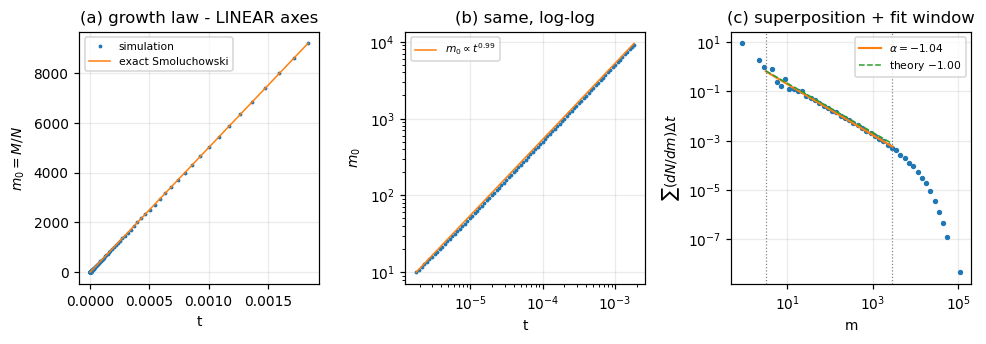

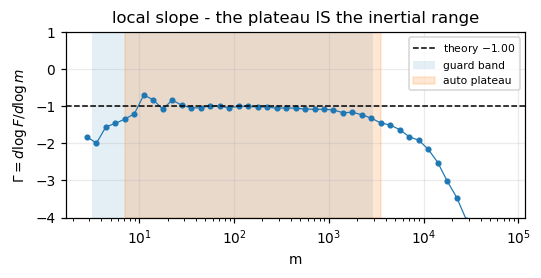

In [13]:
fig, ax = plt.subplots(1, 3)
ax[0].plot(r1["t"], r1["m_mean"], ".", ms=3, label="simulation")
ax[0].plot(r1["t"], exact, "-", lw=1, label="exact Smoluchowski")
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$m_0=M/N$"); ax[0].legend(fontsize=7)
ax[0].set_title("(a) growth law - LINEAR axes")

tt = r1["t"][sel]
ax[1].loglog(tt, r1["m_mean"][sel], ".", ms=3)
ax[1].loglog(tt, r1["m_mean"][sel][0]*(tt/tt[0])**g1["b"], "-", lw=1,
             label=r"$m_0\propto t^{%.2f}$" % g1["b"])
ax[1].set_xlabel("t"); ax[1].set_ylabel(r"$m_0$"); ax[1].legend(fontsize=7)
ax[1].set_title("(b) same, log-log")

# (c) superposed spectrum with the fit windows marked
ax[2].loglog(r1["centers"], np.where(F1>0, F1, np.nan), "o", ms=2.5)
xs = np.logspace(np.log10(gb1[0]), np.log10(gb1[1]), 30)
ax[2].loglog(xs, f1["A"]*xs**f1["alpha"], "-", lw=1.4, label=r"$\alpha=%.2f$" % f1["alpha"])
ax[2].loglog(xs, f1["A"]*xs**pr1["alpha"], "--", lw=1, label=r"theory $%.2f$" % pr1["alpha"])
for v in gb1: ax[2].axvline(v, ls=":", lw=.8, color="0.5")
ax[2].set_xlabel("m"); ax[2].set_ylabel(r"$\sum (dN/dm)\Delta t$")
ax[2].legend(fontsize=7); ax[2].set_title("(c) superposition + fit window")
fig.tight_layout()

# --- the diagnostic that decides the window: local slope -------------------
fig2, a2 = plt.subplots(figsize=(5,2.6))
mm, G = BF.local_slope(r1["centers"], F1)
a2.semilogx(mm, G, "o-", ms=3, lw=.8)
a2.axhline(pr1["alpha"], ls="--", lw=1, color="k", label=r"theory $%.2f$" % pr1["alpha"])
a2.axvspan(gb1[0], gb1[1], alpha=.12, label="guard band")
if np.isfinite(ir1["m_lo"]):
    a2.axvspan(ir1["m_lo"], ir1["m_hi"], alpha=.18, color="C1", label="auto plateau")
a2.set_ylim(-4, 1); a2.set_xlabel("m"); a2.set_ylabel(r"$\Gamma=d\log F/d\log m$")
a2.legend(fontsize=7); a2.set_title("local slope - the plateau IS the inertial range")
fig2.tight_layout()

---
## 2. Closed system + fragmentation

Mirror image of case 1. Mass again exactly conserved; `min_frag_mass` is a **passive** floor
(particles below it stop fragmenting), so nothing is removed.

Exact reference: $n(t)=n_0/(1-n_0K_1t/2)$, hence $m_0(t)=m_{\rm i}(1-n_0K_1t/2)$ — again a
**straight line on linear axes**, now sloping down, reaching zero at $t_*=2/(n_0K_1)$.
Same $b=1$, same $\alpha=-1$: *the exponents do not know which way the cascade runs.*

In [4]:
# No thinning: N grows as m_i/m0, so the range is capped by MEMORY.
# live_end ~ N0 * (m_init/floor); keep that under a few million.
N0F, M_INIT_F, FLOOR = 3000, 1e3, 1.0          # ~3 decades, live_end ~ 3e6
r2 = BF.simulate(process="fragmentation", system="closed", kernel=KERNEL, edges=EDGES,
                 ic={"m":M_INIT_F, "N":N0F}, min_frag_mass=FLOOR,
                 snapshot_mode="log_m0", snapshot_stride=30, max_events=4e6,
                 rng=np.random.default_rng(2), verbose=False)

print("snapshots = %d | live: %d -> %d | w = %.3g (constant) | mass_drift = %+.2e (must be 0)"
      % (len(r2["t"]), r2["live"][0], r2["live"][-1], r2["final_weight"], r2["mass_drift"]))
dt2 = np.diff(r2["t"], prepend=r2["t"][0])
print("snapshots = %d | weight of the LAST snapshot = %.2f%%  (must be << 1%%)"
      % (len(r2["t"]), 100*dt2[-1]/dt2.sum()))

print("live %d -> %d | <m> %.4g -> %.4g" % (r2["live"][0], r2["live"][-1],
                                            r2["m_mean"][0], r2["m_mean"][-1]))
print("mass conserved: %.8g -> %.8g" % (r2["M_sys"][0], r2["M_sys"][-1]))

sel2   = r2["m_mean"] > 3
r2_lin = np.corrcoef(r2["t"][sel2], r2["m_mean"][sel2])[0,1]**2
r2_exp = np.corrcoef(r2["t"][sel2], np.log(r2["m_mean"][sel2]))[0,1]**2
print("\nm0(t): LINEAR R2 = %.5f   EXPONENTIAL R2 = %.5f   <-- linear must win" % (r2_lin, r2_exp))

p      = np.polyfit(r2["t"][sel2], r2["m_mean"][sel2], 1); t_star = -p[1]/p[0]
g2     = BF.growth_fit(r2["t"], r2["m_mean"], t_star=t_star*1.0000001, mask=sel2)
F2     = BF.superpose(r2["dndm"], r2["t"])
ir2    = BF.find_inertial_range(r2["centers"], F2)
gb2    = BF.guard_band(r2["m_mean"][-1], M_INIT_F, 0.5)      # closed frag: [m0_end, m_i]
f2     = BF.fit_powerlaw(r2["centers"], F2, *gb2)
pr2    = BF.predict("closed", LAM)
print("decay law   : b = %.3f  (theory %.3f)  in (t*-t), t* = %.4g" % (g2["b"], pr2["b"], t_star))
print("spectrum, guard band [%.3g,%.3g] : alpha = %+.3f  (theory %+.3f)  R2=%.3f"
      % (gb2[0], gb2[1], f2["alpha"], pr2["alpha"], f2["r2"]))
print("spectrum, auto plateau [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades"
      % (ir2["m_lo"], ir2["m_hi"], ir2["alpha"], ir2["scatter"], ir2["decades"]))
RESULTS["2 closed frag"] = (g2["b"], f2["alpha"], pr2)

snapshots = 95 | live: 3000 -> 4003000 | w = 1 (constant) | mass_drift = +0.00e+00 (must be 0)
snapshots = 95 | weight of the LAST snapshot = 0.02%  (must be << 1%)
live 3000 -> 4003000 | <m> 1000 -> 0.7494
mass conserved: 3000000 -> 3000000

m0(t): LINEAR R2 = 1.00000   EXPONENTIAL R2 = 0.68289   <-- linear must win
decay law   : b = 0.980  (theory 1.000)  in (t*-t), t* = 0.0006671
spectrum, guard band [2.37,316] : alpha = -1.094  (theory -1.000)  R2=1.000
spectrum, auto plateau [0.000355,0.447] : alpha = -0.008 +- 0.050  over 3.10 decades


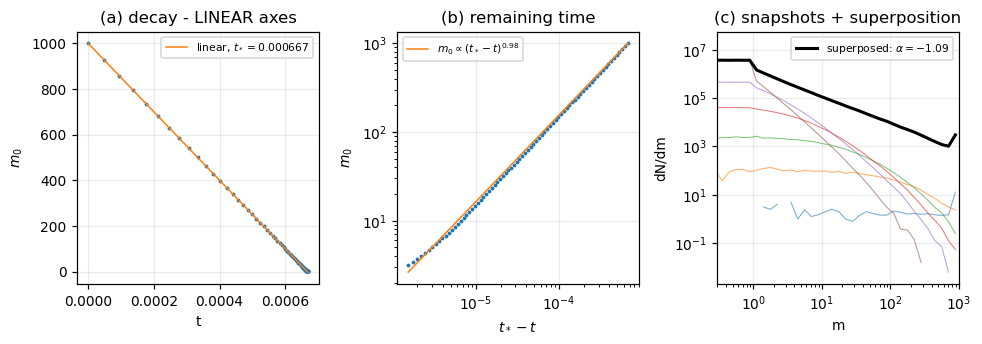

In [5]:
fig, ax = plt.subplots(1, 3)
ax[0].plot(r2["t"], r2["m_mean"], ".", ms=3)
tt = np.linspace(0, r2["t"][-1], 50)
ax[0].plot(tt, np.polyval(p, tt), "-", lw=1, label=r"linear, $t_*=%.3g$" % t_star)
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$m_0$"); ax[0].legend(fontsize=7)
ax[0].set_title("(a) decay - LINEAR axes")

x = t_star*1.0000001 - r2["t"][sel2]
ax[1].loglog(x, r2["m_mean"][sel2], ".", ms=3)
ax[1].loglog(x, r2["m_mean"][sel2][0]*(x/x[0])**g2["b"], "-", lw=1,
             label=r"$m_0\propto (t_*-t)^{%.2f}$" % g2["b"])
ax[1].set_xlabel(r"$t_*-t$"); ax[1].set_ylabel(r"$m_0$"); ax[1].legend(fontsize=7)
ax[1].set_title("(b) remaining time")

for k in np.linspace(3, len(r2["t"])-1, 6).astype(int):
    ax[2].loglog(r2["centers"], np.where(r2["dndm"][k]>0, r2["dndm"][k], np.nan), lw=.7, alpha=.6)
ax[2].loglog(r2["centers"], np.where(F2>0, F2/F2.max()*r2["dndm"].max(), np.nan), "k", lw=2,
             label=r"superposed: $\alpha=%.2f$" % f2["alpha"])
ax[2].set_xlim(.3, 1e3); ax[2].set_xlabel("m"); ax[2].set_ylabel("dN/dm")
ax[2].legend(fontsize=7); ax[2].set_title("(c) snapshots + superposition")
fig.tight_layout()

---
## 3. Open system + coagulation

Injection of monomers at $m_{\rm inj}$, absorbing sink at $m_{\rm sink}$. A genuine steady
state now exists, and **the spectrum is the last snapshot, not a superposition**.

Steady-state estimate for the injection rate (constant kernel, $V=1$): the accepted event
rate is $\simeq N^2/2$, so $q\simeq N_{\rm ss}^2/2$ up to the number of mergers each monomer
needs. Tune `q` until `live` plateaus and $M_{\rm out}/M_{\rm in}\to1$.

The growth law is measured from the **isochrones** — the accumulated 2D histogram in
(age, mass) — as $\langle m\rangle(\tau)\propto\tau^{\,b}$ with $b=2/(1-\lambda)=2$.

In [6]:
# OPEN system: the steady state is the LAST snapshot, dt never enters the estimator,
# so snapshotting by events is perfectly fine here.
N_SS = 10000
q3   = 0.5 * N_SS**2
r3 = BF.simulate(process="coagulation", system="open", kernel=KERNEL, edges=EDGES,
                 ic={"m":1.0, "N":N_SS}, injection_rate=q3, injection_mass=1.0, sink_mass=1e3,
                 snapshot_mode="events", snapshot_stride=50000, max_events=1.2e6,
                 iso_age_edges=10.0**np.arange(-7,-1,0.15), iso_t_start=2e-3,
                 age_rule="min",        # <-- report this; try 'mass_weighted' to test sensitivity
                 rng=np.random.default_rng(3), verbose=False)

print("live %d -> %d   (must plateau)" % (r3["live"][0], r3["live"][-1]))
print("M_out/M_in = %.3f   (must approach 1)" % (r3["M_out"][-1]/max(r3["M_in"][-1],1)))

last3 = r3["dndm"][-1]
gb3   = BF.guard_band(1.0, 1e3, 0.5)            # open: between injection and sink
ir3   = BF.find_inertial_range(r3["centers"], last3)
f3    = BF.fit_powerlaw(r3["centers"], last3, *gb3)
tau3, mbar3, n3 = BF.iso_mean_mass(r3["iso_counts"], r3["centers"], r3["iso_age_edges"])
k3 = np.isfinite(mbar3) & (n3 > 1e3) & (mbar3 > 3) & (mbar3 < 300)
b3 = np.polyfit(np.log(tau3[k3]), np.log(mbar3[k3]), 1)[0] if k3.sum() > 3 else np.nan
pr3 = BF.predict("open", LAM)

print("\nspectrum, guard band [%.3g,%.3g] : alpha = %+.3f  (theory %+.3f)  R2=%.3f"
      % (gb3[0], gb3[1], f3["alpha"], pr3["alpha"], f3["r2"]))
print("spectrum, auto plateau [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades"
      % (ir3["m_lo"], ir3["m_hi"], ir3["alpha"], ir3["scatter"], ir3["decades"]))
print("isochrone growth         : b = %.3f   (theory %.3f)   [%d age bins]" % (b3, pr3["b"], k3.sum()))
RESULTS["3 open coag"] = (b3, f3["alpha"], pr3)

live 10000 -> 9995   (must plateau)
M_out/M_in = 0.808   (must approach 1)

spectrum, guard band [3.16,316] : alpha = -1.458  (theory -1.500)  R2=0.974
spectrum, auto plateau [14.1,708] : alpha = -1.357 +- 0.110  over 1.70 decades
isochrone growth         : b = 1.812   (theory 2.000)   [8 age bins]


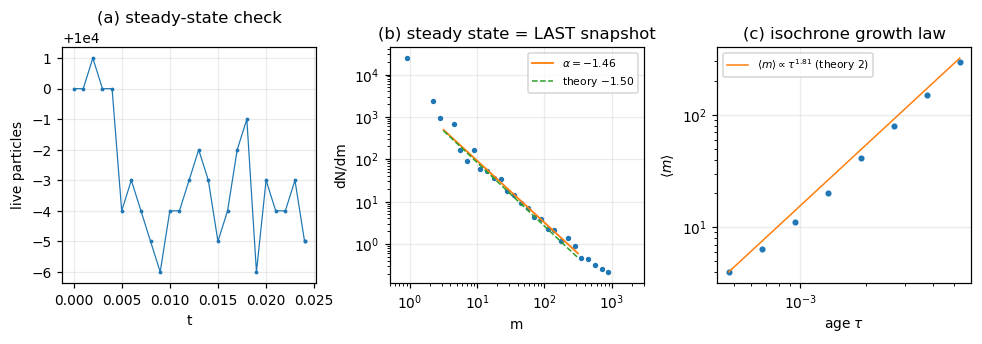

In [7]:
fig, ax = plt.subplots(1, 3)
ax[0].plot(r3["t"], r3["live"], ".-", ms=3, lw=.8)
ax[0].set_xlabel("t"); ax[0].set_ylabel("live particles"); ax[0].set_title("(a) steady-state check")

ax[1].loglog(r3["centers"], np.where(last3>0, last3, np.nan), "o", ms=2.5)
xs = np.logspace(np.log10(gb3[0]), np.log10(gb3[1]), 30)
ax[1].loglog(xs, f3["A"]*xs**f3["alpha"], "-", lw=1.2, label=r"$\alpha=%.2f$" % f3["alpha"])
ax[1].loglog(xs, f3["A"]*xs**pr3["alpha"], "--", lw=1, label=r"theory $%.2f$" % pr3["alpha"])
ax[1].set_xlim(.5, 3e3); ax[1].set_xlabel("m"); ax[1].set_ylabel("dN/dm")
ax[1].legend(fontsize=7); ax[1].set_title("(b) steady state = LAST snapshot")

ax[2].loglog(tau3[k3], mbar3[k3], "o", ms=3)
ax[2].loglog(tau3[k3], mbar3[k3][0]*(tau3[k3]/tau3[k3][0])**b3, "-", lw=1,
             label=r"$\langle m\rangle\propto\tau^{%.2f}$ (theory %.0f)" % (b3, pr3["b"]))
ax[2].set_xlabel(r"age $\tau$"); ax[2].set_ylabel(r"$\langle m\rangle$")
ax[2].legend(fontsize=7); ax[2].set_title("(c) isochrone growth law")
fig.tight_layout()

---
## 4. Open system + fragmentation

Injection of **large** bodies at $m_{\rm inj}$, absorbing sink at **small** $m_{\rm sink}$.
Mirror of case 3, and the theory predicts the same $\alpha=-(3+\lambda)/2$.

### The locality trap — run this one twice

If the rule is *"the heavier of the pair breaks, whatever hit it"*, the disruption rate of a
particle of mass $m_0$ is

$$\nu(m_0)\sim\int_{m_{\rm sink}}^{m_0}F(m')\,K(m_0,m')\,dm'\ \sim\ \int_{m_{\rm sink}/m_0}x^{\alpha}\,dx ,$$

which **diverges at the lower limit whenever $\alpha<-1$**. The drift is then controlled by
the smallest particles in the box — by the sink scale, not by $m_0$ — the mean-field closure
is void, $\beta\to1$, and the measured index locks onto $-2$ for *any* kernel. That is a
boundary effect masquerading as universality.

The cure is the one Dohnanyi (1969) built in: a **catastrophic-disruption threshold**. A
grain of dust does not shatter a boulder. Requiring $m_{\rm small}\ge f\,m_{\rm large}$ with
$f=O(0.1\!-\!1)$ restricts the integral to $x\in[f,1]$, which is scale free, and recovers
$\alpha=-(3+\lambda)/2$.

A **closed** system is immune, because its packet is narrow and all partners are already of
order $m_0$ — which is why cases 1 and 2 agree with the theory with no threshold at all.

In [8]:
M_INJ4, M_SINK4 = 100.0, 1.0
q4 = 0.5*(1.0e4)**2 / (M_INJ4/M_SINK4)

runs4 = {}
for f_ratio in (0.0, 0.3):
    runs4[f_ratio] = BF.simulate(
        process="fragmentation", system="open", kernel=KERNEL, edges=EDGES,
        ic={"m":M_INJ4, "N":1000}, frag_min_ratio=f_ratio,
        injection_rate=q4/max(f_ratio,0.15)*0.15,
        injection_mass=M_INJ4, sink_mass=M_SINK4,
        snapshot_mode="events", snapshot_stride=60000, max_events=9e5,
        rng=np.random.default_rng(4), verbose=False)

pr4 = BF.predict("open", LAM)
print("theory alpha = %+.3f\n" % pr4["alpha"])
for f_ratio, r in runs4.items():
    fit = BF.fit_powerlaw(r["centers"], r["dndm"][-1], *BF.guard_band(M_SINK4, M_INJ4, 0.4))
    tag = "NON-LOCAL (no threshold)" if f_ratio == 0 else ("local, f = %.2g" % f_ratio)
    print("  %-26s live %d->%d  M_out/M_in=%.2f  alpha = %+.3f  R2=%.3f" %
          (tag, r["live"][0], r["live"][-1],
           r["M_out"][-1]/max(r["M_in"][-1],1), fit["alpha"], fit["r2"]))

r4 = runs4[0.3]
f4 = BF.fit_powerlaw(r4["centers"], r4["dndm"][-1], *BF.guard_band(M_SINK4, M_INJ4, 0.4))
RESULTS["4 open frag"] = (np.nan, f4["alpha"], pr4)

theory alpha = -1.500

  NON-LOCAL (no threshold)   live 1000->13992  M_out/M_in=1.14  alpha = -2.082  R2=0.997
  local, f = 0.3             live 1000->14083  M_out/M_in=0.94  alpha = -1.440  R2=0.991


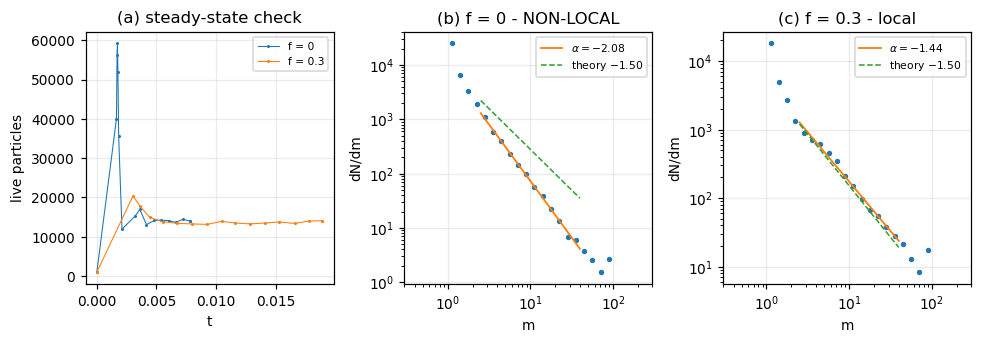

In [9]:
fig, ax = plt.subplots(1, 3)
for f_ratio, r in runs4.items():
    ax[0].plot(r["t"], r["live"], ".-", ms=2, lw=.7, label="f = %.2g" % f_ratio)
ax[0].set_xlabel("t"); ax[0].set_ylabel("live particles"); ax[0].legend(fontsize=7)
ax[0].set_title("(a) steady-state check")

for i, (f_ratio, r) in enumerate(runs4.items()):
    last = r["dndm"][-1]
    gb4  = BF.guard_band(M_SINK4, M_INJ4, 0.4)
    fit  = BF.fit_powerlaw(r["centers"], last, *gb4)
    a = ax[1+i]
    a.loglog(r["centers"], np.where(last>0, last, np.nan), "o", ms=2.5)
    xs = np.logspace(np.log10(gb4[0]), np.log10(gb4[1]), 30)
    a.loglog(xs, fit["A"]*xs**fit["alpha"], "-", lw=1.2, label=r"$\alpha=%.2f$" % fit["alpha"])
    a.loglog(xs, fit["A"]*xs**pr4["alpha"], "--", lw=1, label=r"theory $%.2f$" % pr4["alpha"])
    a.set_xlim(.3, 3e2); a.set_xlabel("m"); a.set_ylabel("dN/dm"); a.legend(fontsize=7)
    a.set_title("(b) f = 0 - NON-LOCAL" if f_ratio == 0 else "(c) f = %.2g - local" % f_ratio)
fig.tight_layout()

---
## 5. Where the baseline runs out — the two walls, measured

Without weights the range is bounded from both sides, and by different things.

**Coagulation: the population is spent.** $N=N_{\rm i}m_{\rm i}/m_0$, so each decade of $m_0$ costs a
factor ten in surviving particles. Push too far and the run ends with a handful — in a test at
$N_{\rm i}=2\times10^5$ it finished with **one particle alive**, and the usable plateau collapsed
from 5.6 decades to 2.7.

**Fragmentation: memory is spent.** $N$ grows as $m_{\rm i}/m_0$, so three decades multiply the
population a thousandfold.

The cell below sweeps $N_{\rm i}$ for the coagulation case and shows the wall directly: decades
reached, particles left at the top, and the width of the fitted plateau. Compare with `BF.py`,
where the same ten decades cost $4.5\times10^5$ events and returned $\alpha=-1.005$ against a
theoretical $-1.000$.

In [10]:
print("%10s %9s %9s %9s %9s %9s" % ("N_i", "decades", "live_end", "events", "alpha", "plateau"))
print("-"*62)
for N0s in (1e4, 1e5, 1e6):
    r = BF.simulate(process="coagulation", system="closed", kernel=BF.kernel_constant,
                    edges=10.0**np.arange(-4, 12, 0.1), ic={"m":1.0, "N":int(N0s)},
                    stop_max_mass=1e9, snapshot_mode="log_m0", snapshot_stride=30,
                    rng=np.random.default_rng(5), verbose=False)
    F  = BF.superpose(r["dndm"], r["t"])
    gb = BF.guard_band(1.0, r["m_mean"][-1], 0.5)
    f  = BF.fit_powerlaw(r["centers"], F, *gb)
    ir = BF.find_inertial_range(r["centers"], F)
    print("%10.0e %9.2f %9.0f %9.2e %+9.3f %6.2f dec"
          % (N0s, np.log10(r["m_mean"][-1]), r["live"][-1], r["events"][-1],
             f["alpha"], ir["decades"]))
print("\ntheory alpha = -1.000;  usable decades ~ log10(N_i) - 3")
print("with BF.py (resampling on): 9.04 decades, 4.5e5 events, alpha = -1.005, plateau 7.80 dec")

       N_i   decades  live_end    events     alpha   plateau
--------------------------------------------------------------
     1e+04      4.00         1  1.00e+04    -1.078   1.40 dec
     1e+05      5.00         1  1.00e+05    -1.056   2.50 dec
     1e+06      6.00         1  1.00e+06    -1.077   3.60 dec

theory alpha = -1.000;  usable decades ~ log10(N_i) - 3
with BF.py (resampling on): 9.04 decades, 4.5e5 events, alpha = -1.005, plateau 7.80 dec


---
## Summary — measured against the analytic laws

Read the table as the statement the analytic section makes: **coagulation and fragmentation
are the same cascade run in opposite directions.** They share $\beta$, share the growth
exponent $b$, and share the spectral index $\alpha$. The direction fixes only which end
carries the source, whether $m_0$ is read in $\tau$ or in $\tau_*-\tau$, whether the particle
budget is bounded ($\le N_{\rm i}$ events, coagulation) or unbounded (fragmentation), and —
separately — whether the fragmentation rule is local.

In [11]:
print("kernel %s, lambda = %.4g\n" % (KERNEL.__name__, LAM))
print("%-16s %9s %9s %11s %13s" % ("case", "b meas", "b theory", "alpha meas", "alpha theory"))
print("-"*63)
for name, (b, a, pr) in RESULTS.items():
    bm = "   --" if not np.isfinite(b) else "%9.3f" % b
    print("%-16s %9s %9.3f %11.3f %13.3f" % (name, bm, pr["b"], a, pr["alpha"]))

ratio = BF.predict("open", LAM)["b"] / BF.predict("closed", LAM)["b"]
print("\nStructural checks:")
print("  b_open / b_closed = %.3f    (theory 2, for every lambda)" % ratio)
print("  coagulation vs fragmentation: identical exponents in both systems")
print("  the two branches meet only at lambda = 1, where beta = 1 and alpha = -2")

kernel kernel_constant, lambda = 0

case                b meas  b theory  alpha meas  alpha theory
---------------------------------------------------------------
1 closed coag        0.985     1.000      -1.061        -1.000
2 closed frag        0.980     1.000      -1.094        -1.000
3 open coag          1.812     2.000      -1.458        -1.500
4 open frag             --     2.000      -1.440        -1.500

Structural checks:
  b_open / b_closed = 2.000    (theory 2, for every lambda)
  coagulation vs fragmentation: identical exponents in both systems
  the two branches meet only at lambda = 1, where beta = 1 and alpha = -2


---
## Next runs worth doing

1. **Geometric kernel**, `KERNEL = BF.kernel_geometric` ($\lambda=2/3$): predicts
   $\alpha=-5/3$ closed and $-11/6\simeq-1.833$ open, with $b=3$ and $6$. The open value is
   the one already measured at $-1.815$ with the previous code.
2. **The marginal kernel**, `BF.kernel_additive` ($\lambda=1$): both branches should collapse
   onto $\alpha=-2$ and the drift should become exponential — $\ln m_0$ linear in $\tau$, this
   time genuinely, not as a clock artefact. This is the one case where the exponential fit
   *should* win.
3. **Age-rule sensitivity** (case 3): rerun with `age_rule="mass_weighted"` and `"heavier"`.
   The isochrone growth exponent must not move; if it does, the cohort decomposition for
   coagulation is not well posed and must be reported as such.
4. **Loss (siphon)**: a mass-independent removal rate $\xi$ should steepen coagulation to
   $\alpha-\xi/D$ and flatten fragmentation to $\alpha+\xi/D$. The sign flip is a genuine
   prediction: the age increases *with* $m_0$ in one case and *against* it in the other.